In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install git+https://github.com/amazon-science/chronos-forecasting.git
!pip install pandas torch matplotlib numpy pyarrow fastparquet

In [ ]:
import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
from chronos import BaseChronosPipeline, Chronos2Pipeline
from peft import LoraConfig
import itertools


In [ ]:
pipeline: Chronos2Pipeline = BaseChronosPipeline.from_pretrained("amazon/chronos-2", device_map="cuda", torch_dtype=torch.bfloat16)

AssertionError: Torch not compiled with CUDA enabled

In [ ]:
PREDICTION_LENGTH = 96
base_dir = DATA_PATH = "/content/drive/MyDrive/FM_project/dataset"
train_path = os.path.join(base_dir, "skippd_train_aligned_v13_with_time_features_and_sky_features.parquet")
#train_path = os.path.join(base_dir, "skippd_train_aligned_v13_with_time_features_no_images.parquet")

In [ ]:
COVARIATE_COLUMNS = list()

In [ ]:
def load_and_prepare(path):
    print(f"Loading {path}...")
    df = pd.read_parquet(path)
    if "image" in df.columns:
      print("Dropping raw 'image' column (dictionaries)...")
    df = df.drop(columns=["image"])

    # 1. Rename columns
    column_mapping = {
        "time": "timestamp",
        "series_id": "item_id",
        "pv": "pv_value"
    }


    df = df.rename(columns={k: v for k, v in column_mapping.items() if k in df.columns})

    # 2. Timestamp Conversion
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    if df['timestamp'].dt.tz is not None:
        df['timestamp'] = df['timestamp'].dt.tz_localize(None)

    reserved_columns = ['timestamp', 'item_id', 'pv_value']

    COVARIATE_COLUMNS = [col for col in df.columns if col not in reserved_columns]

    print(f" Automatically identified {len(COVARIATE_COLUMNS)} covariates: {COVARIATE_COLUMNS}")

    # 3. Check Covariates
    missing_covariates = [col for col in COVARIATE_COLUMNS if col not in df.columns]
    if missing_covariates:
        raise ValueError(f"Missing required covariate columns: {missing_covariates}")

    # --- UPDATED LOGIC FOR MULTIPLE SERIES ---

    # 4. Filter out series that are too short
    # We need at least prediction_length + 1 data point to have a training set
    item_counts = df.groupby('item_id').size()
    valid_items = item_counts[item_counts > PREDICTION_LENGTH].index

    if len(valid_items) < len(item_counts):
        print(f"Dropping {len(item_counts) - len(valid_items)} series that are too short.")
        df = df[df['item_id'].isin(valid_items)].copy()

    # 5. Sort by item_id AND timestamp (Critical for correct splitting)
    df = df.sort_values(['item_id', 'timestamp']).reset_index(drop=True)

    # 6. Global Split
    print(f"Splitting data for {len(valid_items)} time series...")

    # Inference/Test: Grab the last PREDICTION_LENGTH rows for EACH item_id
    test_df = df.groupby('item_id').tail(PREDICTION_LENGTH).copy()

    # Train: Drop the rows that belong to test_df
    # (Since we reset_index above, the indices are unique and safe to use for dropping)
    train_df = df.drop(test_df.index).copy()

    # 7. Create Inference input (Drop target)
    inference_df = test_df.copy()
    if 'pv_value' in inference_df.columns:
        inference_df = inference_df.drop(columns=['pv_value'])

    print(f"Train shape: {train_df.shape}")
    print(f"Inference/Test shape: {inference_df.shape}")

    return train_df, inference_df, test_df

In [ ]:
load_and_prepare(train_path)

Loading /content/drive/MyDrive/FM_project/dataset/skippd_train_aligned_v13_with_time_features_and_sky_features.parquet...
Dropping raw 'image' column (dictionaries)...
 Automatically identified 13 covariates: ['time_hour_sin', 'time_hour_cos', 'time_dayofyear_sin', 'sky_feature_0', 'sky_feature_1', 'sky_feature_2', 'sky_feature_3', 'sky_feature_4', 'sky_feature_5', 'sky_feature_6', 'sky_feature_7', 'sky_feature_8', 'sky_feature_9']
Splitting data for 3 time series...
Train shape: (18379, 16)
Inference/Test shape: (288, 15)


(                timestamp  pv_value  item_id  time_hour_sin  time_hour_cos  \
 0     2017-05-08 07:30:00  0.000000        0          0.966         -0.259   
 1     2017-05-08 08:00:00  0.286534        0          0.866         -0.500   
 2     2017-05-08 08:30:00  0.769674        0          0.866         -0.500   
 3     2017-05-08 09:00:00  2.747408        0          0.707         -0.707   
 4     2017-05-08 09:30:00  6.135439        0          0.707         -0.707   
 ...                   ...       ...      ...            ...            ...   
 18566 2018-10-01 21:30:00  0.000000        2         -0.707          0.707   
 18567 2018-10-01 22:00:00  0.000000        2         -0.500          0.866   
 18568 2018-10-01 22:30:00  0.000000        2         -0.500          0.866   
 18569 2018-10-01 23:00:00  0.000000        2         -0.259          0.966   
 18570 2018-10-01 23:30:00  0.000000        2         -0.259          0.966   
 
        time_dayofyear_sin  sky_feature_0  sky_fea

In [ ]:
# Energy price forecasting configuration
target = "pv_value"  # Column name containing the values to forecast (energy prices)
prediction_length = PREDICTION_LENGTH  # Number of hours to forecast ahead
id_column = "item_id"  # Column identifying different time series (countries/regions)
timestamp_column = "timestamp"  # Column containing datetime information
timeseries_id = 0 # Specific time series to visualize (Germany)

train_df, inference_df, test_df =load_and_prepare(train_path)
#display(train_df.head())
#display(inference_df.head())
#display(test_df.head())


In [ ]:
# Generate predictions with covariates
pred_df = pipeline.predict_df(
    df=train_df,
    future_df=inference_df,
    prediction_length=prediction_length,
    quantile_levels=[0.1, 0.5, 0.9],
    id_column=id_column,
    timestamp_column=timestamp_column,
    target=target,
)
#display(pred_df.head())

In [ ]:
# Visualization helper function
def plot_forecast(
    context_df: pd.DataFrame,
    pred_df: pd.DataFrame,
    test_df: pd.DataFrame,
    target_column: str,
    timeseries_id: str,
    id_column: str = "id",
    timestamp_column: str = "timestamp",
    history_length: int = 256,
    title_suffix: str = "",
):
    ts_context = context_df.query(f"{id_column} == @timeseries_id").set_index(timestamp_column)[target_column]
    ts_pred = pred_df.query(f"{id_column} == @timeseries_id and target_name == @target_column").set_index(
        timestamp_column
    )[["0.1", "predictions", "0.9"]]
    ts_ground_truth = test_df.query(f"{id_column} == @timeseries_id").set_index(timestamp_column)[target_column]

    last_date = ts_context.index.max()
    start_idx = max(0, len(ts_context) - history_length)
    plot_cutoff = ts_context.index[start_idx]
    ts_context = ts_context[ts_context.index >= plot_cutoff]
    ts_pred = ts_pred[ts_pred.index >= plot_cutoff]
    ts_ground_truth = ts_ground_truth[ts_ground_truth.index >= plot_cutoff]

    fig = plt.figure(figsize=(12, 3))
    ax = fig.gca()
    ts_context.plot(ax=ax, label=f"historical {target_column}", color="xkcd:azure")
    ts_ground_truth.plot(ax=ax, label=f"future {target_column} (ground truth)", color="xkcd:grass green")
    ts_pred["predictions"].plot(ax=ax, label="forecast", color="xkcd:violet")
    ax.fill_between(
        ts_pred.index,
        ts_pred["0.1"],
        ts_pred["0.9"],
        alpha=0.7,
        label="prediction interval",
        color="xkcd:light lavender",
    )
    ax.axvline(x=last_date, color="black", linestyle="--", alpha=0.5)
    ax.legend(loc="upper left")
    ax.set_title(f"{target_column} forecast for {timeseries_id} {title_suffix}")
    fig.show()

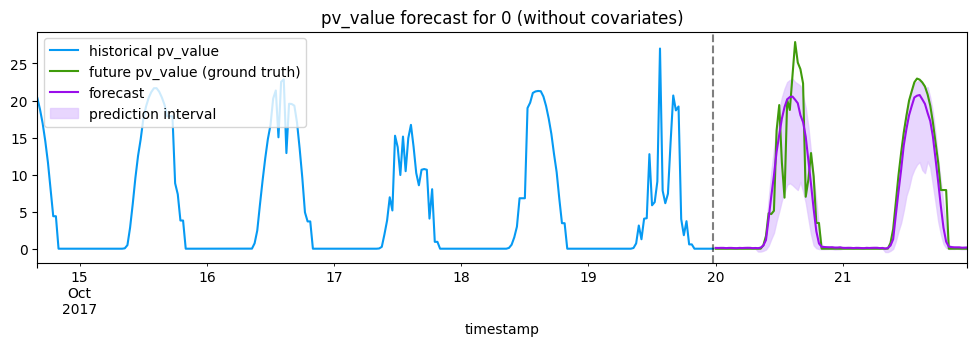

In [ ]:
# Compare: forecast without covariates
energy_pred_no_cov_df = pipeline.predict_df(
    train_df[[id_column, timestamp_column, target]],
    future_df=None,
    prediction_length=prediction_length,
    quantile_levels=[0.1, 0.5, 0.9],
    id_column=id_column,
    timestamp_column=timestamp_column,
    target=target
)

plot_forecast(
    train_df,
    energy_pred_no_cov_df,
    test_df,
    target_column=target,
    timeseries_id=timeseries_id,
    id_column=id_column
    title_suffix="(without covariates)",
)

In [ ]:

# Prepare data for fine-tuning using the retail sales dataset
known_covariates = COVARIATE_COLUMNS
past_covariates = ["Customers"]


train_inputs = []
for item_id, group in train_df.groupby("item_id"):

    covariates_dict = {col: group[col].values for col in COVARIATE_COLUMNS}

    train_inputs.append({
        "target": group[target].values,
        "past_covariates": covariates_dict,#{col: group[col].values for col in past_covariates + known_covariates},
        # Future values of covariates are not used during training.
        # However, we need to include their names to indicate that these columns will be available at prediction time
        #"future_covariates": covariates_dict,#{col: None for col in known_covariates},
        "future_covariates": {col: None for col in known_covariates}
    })

NameError: name 'COVARIATE_COLUMNS' is not defined

In [ ]:
dora_config = LoraConfig(
    r=16,                    # Rank (same as default or adjust as needed)
    lora_alpha=32,           # Alpha (scaling factor)
    target_modules=[
        "self_attention.q",
        "self_attention.v",
        "self_attention.k",
        "self_attention.o",
        "output_patch_embedding.output_layer",
    ],
    lora_dropout=0.05,
    bias="none",
    #task_type="CAUSAL_LM",
    use_dora=True            # <--- THIS ENABLES DoRA
)

In [ ]:
# Fine-tune the model with LoRA
lora_finetuned_pipeline = pipeline.fit(
    inputs=train_inputs,
    prediction_length=PREDICTION_LENGTH,
    num_steps=200,
    learning_rate=1e-4,
    batch_size=24, # I use 12 with Dora
    logging_steps=100,
    finetune_mode="lora",
    #lora_config=dora_config,
)

In [ ]:
lora_finetuned_pred_df = lora_finetuned_pipeline.predict_df(
    df=train_df,
    future_df=inference_df,
    prediction_length=prediction_length,
    quantile_levels=[0.1, 0.5, 0.9],
    id_column=id_column,
    timestamp_column=timestamp_column,
    target=target,
)

In [ ]:
import torch
import gc

# 1. Delete the specific model/pipeline variables causing memory usage
# Replace 'lora_finetuned_pipeline' with whatever variable name is holding your model
try:
    #del lora_finetuned_pipeline
    del pipeline
except NameError:
    pass

# 2. Run Python's garbage collection to clean up the deleted variables
gc.collect()

# 3. Clear the PyTorch cache
torch.cuda.empty_cache()

# Optional: Verify memory is cleared
print(f"Allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
print(f"Reserved:  {torch.cuda.memory_reserved() / 1024**3:.2f} GB")

Allocated: 0.47 GB
Reserved:  0.54 GB


In [ ]:
def backtest_model(pipeline, df, num_windows=3, step_size=96, prediction_length=96):
    """
    Performs Rolling Origin Cross-Validation (Backtesting).
    Mimics AutoGluon's num_val_windows logic.
    """
    print(f"\n--- Starting Robust Backtest ({num_windows} windows) ---")

    metrics = {"mase": [], "mape": [], "wmape": []}

    # We iterate backwards: Window 0 is the most recent, Window 1 is previous, etc.
    for window_idx in range(num_windows):
        cutoff_step = window_idx * step_size

        # 1. Create Train/Test Split for this window
        # If window_idx=0, we use full data (minus last 96 for test)
        # If window_idx=1, we cut off the last 96 points entirely, then use the 96 before that for test

        test_df_list = []
        context_df_list = []

        grouped = df.groupby('item_id')

        for item_id, group in grouped:
            # Total available length
            total_len = len(group)

            # The end index for the test set in this window
            # Window 0: end = total_len
            # Window 1: end = total_len - 96
            end_idx = total_len - cutoff_step

            # The start index for the test set (and end index for context)
            split_idx = end_idx - prediction_length

            if split_idx <= 0: continue # Should be handled by filtering, but safety check

            # Extract Data
            # Context: From start to split_idx
            context_data = group.iloc[:split_idx]
            # Ground Truth: From split_idx to end_idx
            ground_truth = group.iloc[split_idx:end_idx]

            context_df_list.append(context_data)
            test_df_list.append(ground_truth)

        # Combine
        window_context_df = pd.concat(context_df_list)
        window_test_df = pd.concat(test_df_list)

        print(f"Window {window_idx+1}/{num_windows}: Predicting...")

        # 2. Predict
        forecast = pipeline.predict_df(
            df=window_context_df, # Historical context
            prediction_length=prediction_length,
            id_column="item_id",
            timestamp_column="timestamp",
            target="pv_value"
        )

        # 3. Evaluate this window
        w_mase, w_mape, w_wmape = [], [], []

        for item_id in window_test_df['item_id'].unique():
            y_pred = forecast[forecast['item_id'] == item_id]['predictions'].values
            y_true = window_test_df[window_test_df['item_id'] == item_id]['pv_value'].values
            y_history = window_context_df[window_context_df['item_id'] == item_id]['pv_value'].values

            if len(y_pred) != len(y_true): continue

            mase = calculate_item_mase(y_true, y_pred, y_history)
            mape = calculate_item_mape(y_true, y_pred)
            wmape= calculate_item_wmape(y_true, y_pred)

            if not np.isinf(mase): w_mase.append(mase)
            if not np.isnan(mape): w_mape.append(mape)
            if not np.isnan(wmape): w_wmape.append(wmape)

        avg_mase = np.mean(w_mase)
        avg_mape = np.mean(w_mape)
        avg_wmape = np.mean(w_wmape)

        metrics["mase"].append(avg_mase)
        metrics["mape"].append(avg_mape)
        metrics["wmape"].append(avg_wmape)

        print(f"Window {window_idx+1} Metrics -> MASE: {avg_mase:.3f}, MAPE: {avg_mape:.1f}%, WMAPE: {avg_wmape:.1f}%")

    print(f"\n--- Robust Result (Average of {num_windows} windows) ---")
    print(f"Robust MASE: {np.mean(metrics['mase']):.3f}")
    print(f"Robust MAPE: {np.mean(metrics['mape']):.1f}%")
    print(f"Robust MAPE: {np.mean(metrics['wmape']):.1f}%")

    return metrics

In [ ]:

full_df = pd.concat([train_df, test_df]).sort_values(['item_id', 'timestamp'])
robust_scores = backtest_model(
    pipeline=lora_finetuned_pipeline,
    df=full_df,
    num_windows=10,
    step_size=PREDICTION_LENGTH
)


--- Starting Robust Backtest (10 windows) ---
Window 1/10: Predicting...
Window 1 Metrics -> MASE: 1.704, MAPE: 255.9%, WMAPE: 40.8%
Window 2/10: Predicting...
Window 2 Metrics -> MASE: 1.317, MAPE: 223.9%, WMAPE: 29.8%
Window 3/10: Predicting...
Window 3 Metrics -> MASE: 1.112, MAPE: 93.6%, WMAPE: 25.9%
Window 4/10: Predicting...
Window 4 Metrics -> MASE: 0.847, MAPE: 160.3%, WMAPE: 23.2%
Window 5/10: Predicting...
Window 5 Metrics -> MASE: 0.588, MAPE: 90.9%, WMAPE: 16.5%
Window 6/10: Predicting...
Window 6 Metrics -> MASE: 0.557, MAPE: 76.1%, WMAPE: 13.2%
Window 7/10: Predicting...
Window 7 Metrics -> MASE: 0.792, MAPE: 84.5%, WMAPE: 21.2%
Window 8/10: Predicting...
Window 8 Metrics -> MASE: 0.546, MAPE: 93.1%, WMAPE: 11.9%
Window 9/10: Predicting...
Window 9 Metrics -> MASE: 0.683, MAPE: 252.9%, WMAPE: 13.3%
Window 10/10: Predicting...
Window 10 Metrics -> MASE: 0.755, MAPE: 87.7%, WMAPE: 14.2%

--- Robust Result (Average of 10 windows) ---
Robust MASE: 0.890
Robust MAPE: 141.9%
R

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Metric Calculation Helper
def calculate_item_mase(y_true, y_pred, y_history, seasonality=96):
    """Calculates MASE for a single item."""
    # Mean Absolute Error of the forecast
    forecast_mae = np.mean(np.abs(y_true - y_pred))

    # Mean Absolute Error of the naive baseline on history
    # (comparing t with t-seasonality)
    if len(y_history) <= seasonality:
        return np.inf # Not enough history for seasonality

    naive_errors = np.abs(y_history[seasonality:] - y_history[:-seasonality])
    naive_mae = np.mean(naive_errors)

    if naive_mae == 0:
        return np.inf

    return forecast_mae / naive_mae

def calculate_item_mape(y_true, y_pred, epsilon=1e-10):
    """
    Calculates Mean Absolute Percentage Error (MAPE).

    Args:
        epsilon (float): Small value to avoid division by zero.
                         Alternatively, you can mask values where y_true == 0.
    """
    # Option A: Add epsilon to avoid zero division (simplest)
    # mape = np.mean(np.abs((y_true - y_pred) / (y_true + epsilon))) * 100

    # Option B: Filter out zeros (standard for PV data)
    # We only compute MAPE when actual production > 0
    mask = y_true > epsilon
    if np.sum(mask) == 0:
        return np.nan # No valid data points (e.g., essentially night time)

    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

    return mape

def calculate_item_wmape(y_true, y_pred):
    """
    Calculates Weighted Mean Absolute Percentage Error (wMAPE).
    This is preferred for intermittent series (like Solar) where y_true can be ~0.
    """
    total_abs_error = np.sum(np.abs(y_true - y_pred))
    total_actuals = np.sum(np.abs(y_true))

    if total_actuals == 0:
        return np.inf

    return (total_abs_error / total_actuals) * 100

# 2. Main Plotting Function
def plot_model_comparison(train_df, test_df, model_predictions,
                          plot_history_length=200, prediction_length=96, seasonality=96):

    # A. Setup Data
    # Concatenate train and test to get the full timeline for plotting context
    full_data = pd.concat([train_df, test_df]).sort_values(['item_id', 'timestamp'])

    item_ids = sorted(full_data['item_id'].unique())
    num_plots = len(item_ids)

    # Safety check for huge datasets
    if num_plots > 20:
        print(f"Warning: Plotting {num_plots} series will create a very large image.")

    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] # Blue, Orange, Green, Red

    # B. Initialize Figure
    fig, axs = plt.subplots(num_plots, 1, figsize=(15, 6 * num_plots), sharex=False)
    if num_plots == 1: axs = [axs] # Ensure axs is always iterable

    print(f"Generating plots for {num_plots} items...")

    for i, item_id in enumerate(item_ids):
        ax = axs[i]

        # --- C. Prepare Series Data ---
        # Filter data for this specific item
        item_full_data = full_data[full_data['item_id'] == item_id].set_index('timestamp')
        item_test_data = test_df[test_df['item_id'] == item_id].set_index('timestamp')
        item_train_data = train_df[train_df['item_id'] == item_id].set_index('timestamp')

        # 1. History Context (for plotting)
        # We grab the last 'plot_history_length' points from training + the prediction window
        history_context = item_full_data.iloc[-(plot_history_length + prediction_length):]

        # 2. Ground Truth (The actual future)
        ground_truth_future = item_test_data['pv_value']

        # 3. History for Metric (for MASE denominator)
        history_for_metric = item_train_data['pv_value'].values

        # --- D. Plot Background ---
        # Plot the actual values (history + future)
        ax.plot(history_context.index, history_context['pv_value'],
                label='Actual Ground Truth', color='black', linewidth=2, alpha=0.6)

        # Highlight the Forecast Window
        if len(ground_truth_future) > 0:
            cutoff_date = ground_truth_future.index[0]
            ax.axvspan(cutoff_date, ground_truth_future.index[-1], color='gray', alpha=0.1, label="Forecast Window")
            ax.axvline(x=cutoff_date, color='black', linestyle=':', linewidth=1)

        # --- E. Plot Each Model ---
        for idx, (model_name, pred_df_all) in enumerate(model_predictions.items()):
            # Filter predictions for this item
            item_preds = pred_df_all[pred_df_all['item_id'] == item_id].set_index('timestamp')

            if item_preds.empty:
                continue

            # 1. Calculate MASE
            try:
                # Align lengths (take last N points if necessary)
                y_pred = item_preds['predictions'].values[-len(ground_truth_future):]
                y_true = ground_truth_future.values[-len(y_pred):]

                mase_score = calculate_item_mase(
                    y_true=y_true,
                    y_pred=y_pred,
                    y_history=history_for_metric,
                    seasonality=seasonality
                )
                # MAPE (Added)
                mape_score = calculate_item_mape(y_true, y_pred)

                wmape = calculate_item_wmape(y_true, y_pred)

                # Create Label
                metrics_label = f"MASE: {mase_score:.2f} | MAPE: {mape_score:.1f}% | wMAPE: {wmape: .1f}"
            except Exception as e:
                metrics_label = "MASE: N/A"

            # 2. Plot Predictions
            color = colors[idx % len(colors)]
            label_text = f'{model_name} | {metrics_label}'

            # Plot Median (prediction)
            ax.plot(item_preds.index, item_preds['predictions'],
                    label=label_text, color=color, linewidth=2, linestyle='--')

            # Plot Quantiles (if available)
            if '0.1' in item_preds.columns and '0.9' in item_preds.columns:
                ax.fill_between(
                    item_preds.index,
                    item_preds['0.1'],
                    item_preds['0.9'],
                    color=color, alpha=0.15
                )

        # --- F. Final Formatting ---
        ax.set_title(f"Item {item_id}: Forecast Comparison", fontsize=14, fontweight='bold')
        ax.set_ylabel("PV Value")
        ax.legend(loc='upper left', fontsize=10, framealpha=0.9)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# --- 3. Execute ---



In [ ]:
# Define the dictionary of models you want to compare
# (Keys will appear in the legend)
models_to_plot = {
    "Zero-Shot (Base)": pred_df,
    "Fine-Tuned (LoRA)": lora_finetuned_pred_df,
    #"restored_adapter": predictions
}

# Run the plot
plot_model_comparison(
    train_df=train_df,
    test_df=test_df,
    model_predictions=models_to_plot,
    plot_history_length=200,   # How many historical steps to show before the forecast
    prediction_length=PREDICTION_LENGTH,
    seasonality=96             # Seasonality for MASE (96 steps = 48 hours for 30min data)
)

SyntaxError: invalid syntax (ipython-input-2601232801.py, line 6)

TODO:
- Plottare un grafico decente
- Far funzionare la grid seatch di LoRA e provare DoRA
- Fare il confronto con gli stessi modelli, senza le feature date dalle immagini

In [ ]:
!zip -r /content/results_manual_chronos2_ft_dora.zip /content/chronos-2-finetuned/ft_dora

  adding: content/chronos-2-finetuned/ft_dora/ (stored 0%)
  adding: content/chronos-2-finetuned/ft_dora/finetuned-ckpt/ (stored 0%)
  adding: content/chronos-2-finetuned/ft_dora/finetuned-ckpt/adapter_config.json (deflated 59%)
  adding: content/chronos-2-finetuned/ft_dora/finetuned-ckpt/README.md (deflated 66%)
  adding: content/chronos-2-finetuned/ft_dora/finetuned-ckpt/adapter_model.safetensors (deflated 18%)


In [ ]:
# CHOOSE BEST PARAM

In [ ]:
import torch
import gc
import sys

def clear_gpu_memory():
    # 1. Delete the specific objects you want to free (if they exist in local scope)
    # We use 'global' to ensure we affect the global namespace if needed,
    # but usually passing variables or handling them before calling this is better.

    # 2. Force Python's Garbage Collector
    gc.collect()

    # 3. Clear PyTorch's VRAM cache
    torch.cuda.empty_cache()

    # 4. (Optional) Clear standard error/output references which can hold memory
    # This is often the "hidden" culprit in Colab
    sys.last_type = None
    sys.last_value = None
    sys.last_traceback = None

In [ ]:
import torch
import gc
import sys
import os
import itertools
import pandas as pd
import multiprocessing as mp

In [ ]:
def run_single_trial(params, trial_idx, output_dir, train_inputs, inference_df,
                     train_df, test_df, PREDICTION_LENGTH, target, id_column, timestamp_column):
    """
    Runs a single trial in a completely isolated process.
    When this function returns, the process dies and OS reclaims ALL VRAM.
    """
    try:
        print(f"\n--- Trial {trial_idx}: {params} ---")

        # 1. Load Model (Inside the process)
        pipeline = BaseChronosPipeline.from_pretrained(
            "amazon/chronos-2",
            device_map="cuda",
            torch_dtype=torch.bfloat16
        )

        # 2. Configure LoRA
        current_dora_config = LoraConfig(
            r=params["lora_rank"],
            lora_alpha=params["lora_rank"] * 2,
            target_modules=[
                "self_attention.q", "self_attention.v", "self_attention.k", "self_attention.o",
                "output_patch_embedding.output_layer",
            ],
            lora_dropout=params["lora_dropout"],
            bias="none",
        )

        # 3. Train
        trial_pipeline = pipeline.fit(
            inputs=train_inputs,
            prediction_length=PREDICTION_LENGTH,
            num_steps=params["num_steps"],
            learning_rate=params["learning_rate"],
            batch_size=32,
            lora_config=current_dora_config,
            finetune_mode="lora",
            logging_steps=100,
        )

        # 4. Predict
        trial_pred_df = trial_pipeline.predict_df(
            df=train_df,
            future_df=inference_df,
            prediction_length=PREDICTION_LENGTH,
            target=target,
            id_column=id_column,
            timestamp_column=timestamp_column
        )

        # 5. Save Predictions
        trial_pred_df["trial_id"] = trial_idx
        trial_pred_df["param_str"] = str(params)
        filename = f"{output_dir}/preds_trial_{trial_idx}.csv"
        trial_pred_df.to_csv(filename, index=False)

        print(f"Saved predictions to {filename}")

        # D. Calculate Error (wMAPE)
        # We calculate the global wMAPE for this trial
        trial_wmapes = []
        trial_mapes = []
        trial_mases = []
        unique_items = trial_pred_df[id_column].unique()

        for item in unique_items:
            y_true = test_df[test_df[id_column] == item][target].values
            y_pred = trial_pred_df[trial_pred_df[id_column] == item]['predictions'].values

            y_history = train_df[train_df[id_column] == item][target].values

            # Align lengths if necessary
            length = min(len(y_true), len(y_pred))
            wmape = calculate_item_wmape(y_true[:length], y_pred[:length])
            mape = calculate_item_mape(y_true[:length], y_pred[:length])
            mase = calculate_item_mase(
                y_true[:length],
                y_pred[:length],
                y_history=y_history,
                seasonality=96  # Ensure this matches your data (96 for 48h of 30min data)
            )


            if not np.isinf(wmape):
                trial_wmapes.append(wmape)
            if not np.isinf(mape):
                trial_mapes.append(mape)
            if not np.isinf(mase):
                trial_mases.append(mase)

        avg_wmape = np.mean(trial_wmapes)
        avg_mape = np.mean(trial_mapes)
        avg_mase = np.mean(trial_mases)
        print(f"Trial Result -> wMAPE: {avg_wmape:.2f}%")
        print(f"Trial Result -> MAPE: {avg_mape:.2f}%")
        print(f"Trial Result -> MASE: {avg_mase:.2f}%")

        # Save result
        result_dict = {
            **params,
            "wmape": avg_wmape,
            "mape": avg_mape,
            "mase": avg_mase
        }

        return result_dict

    except Exception as e:
        print(f"Trial {trial_idx} failed: {e}")
        return None

In [ ]:
def gs_lora_main():
    import os

    output_file = "hyperparameter_search_results.csv"
    file_exists = os.path.isfile(output_file)

    output_dir = "experiment_predictions"
    os.makedirs(output_dir, exist_ok=True)

    # Define the grid of parameters you want to test
    param_grid = {
        "learning_rate": [1e-4, 1e-3],  # LoRA often tolerates higher LRs
        "lora_rank": [8, 16, 32],             # Capacity of the adapter
        "num_steps": [10, 400],               # Duration of training
        "lora_dropout": [0.0, 0.1]
    }

    # Create all combinations
    keys, values = zip(*param_grid.items())
    combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

    print(f"Total combinations to test: {len(combinations)}")
    # Define setup variables (output_dir, file_exists, combinations, etc.)
    # ...

    # Use 'spawn' to ensure a fresh CUDA context
    mp.set_start_method('spawn', force=True)

    results = []

    for i, params in enumerate(combinations):
        # Create a Process for the trial
        # We use a Queue to get the result back from the process
        queue = mp.Queue()

        def wrapper(q, *args):
            res = run_single_trial(*args)
            q.put(res)

        p = mp.Process(target=wrapper, args=(queue, params, i+1, output_dir,
                                             train_inputs, inference_df, train_df, test_df,
                                             PREDICTION_LENGTH, target, id_column, timestamp_column))
        p.start()
        result = queue.get() # Block until result is ready
        p.join() # Clean up process

        if result:
            results.append(result)
            # Save to CSV immediately
            pd.DataFrame([result]).to_csv(
                output_file, mode='a', header=not file_exists, index=False
            )
            file_exists = True

# --- 2. Define Wrapper at Global Scope ---
# This also must be outside gs_lora_main
def worker_wrapper(q, *args):
    result = run_single_trial(*args)
    q.put(result)

# --- 3. Main Execution Function ---
def gs_lora_main():
    output_file = "hyperparameter_search_results.csv"
    file_exists = os.path.isfile(output_file)

    output_dir = "experiment_predictions"
    os.makedirs(output_dir, exist_ok=True)

    # Define parameters
    param_grid = {
        "learning_rate": [1e-4, 1e-3],
        "lora_rank": [8, 16, 32],
        "num_steps": [10, 400],
        "lora_dropout": [0.0, 0.1]
    }

    keys, values = zip(*param_grid.items())
    combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

    print(f"Total combinations to test: {len(combinations)}")

    # Force spawn for CUDA safety
    try:
        mp.set_start_method('spawn', force=True)
    except RuntimeError:
        pass # set_start_method can only be called once

    results = []

    for i, params in enumerate(combinations):
        queue = mp.Queue()

        # Now we pass the GLOBAL function 'worker_wrapper'
        p = mp.Process(
            target=worker_wrapper,
            args=(queue, params, i+1, output_dir, train_inputs, inference_df,
                  train_df, test_df, PREDICTION_LENGTH, target, id_column, timestamp_column)
        )

        p.start()
        result = queue.get() # Block and wait for result
        p.join()

        if result:
            results.append(result)
            pd.DataFrame([result]).to_csv(
                output_file, mode='a', header=not file_exists, index=False
            )
            file_exists = True

# --- 4. Entry Point ---
if __name__ == "__main__":
    # Ensure variables passed to gs_lora_main exist or pass them as args
    # (assuming train_inputs, etc. are defined globally in your notebook/script)
    gs_lora_main()

Total combinations to test: 24


KeyboardInterrupt: 

### TRT LOADED FT MODEL

In [ ]:
import torch
from chronos import BaseChronosPipeline
from peft import PeftModel

# 1. Define paths
base_model_name = "amazon/chronos-2" # Must match exactly what you used for training
checkpoint_path = "chronos-2-finetuned/ft_lora/finetuned-ckpt" # Replace with your actual folder path

# 2. Load the FRESH Base Model
# This loads the heavy pre-trained weights from Amazon
pipeline = BaseChronosPipeline.from_pretrained(
    base_model_name,
    device_map="cuda",
    torch_dtype=torch.bfloat16
)

print("Base model loaded.")

# 3. Attach your LoRA/DoRA Adapter
# We take the internal model from the pipeline and wrap it with your trained adapter
pipeline.model = PeftModel.from_pretrained(
    pipeline.model,
    checkpoint_path
)

print(f"Adapter loaded from {checkpoint_path}. Ready for inference!")

# 4. Run Inference as usual
# (Example using your previous variables)
predictions = pipeline.predict_df(
    df=train_df,
    future_df=inference_df,
    prediction_length=PREDICTION_LENGTH,
    target=target,
    id_column=id_column,
    timestamp_column=timestamp_column
)

# Save or View
predictions.to_csv("inference_from_checkpoint.csv", index=False)
print("Inference complete.")

Base model loaded.
Adapter loaded from chronos-2-finetuned/ft_lora/finetuned-ckpt. Ready for inference!
Inference complete.


Generating plots for 3 items...


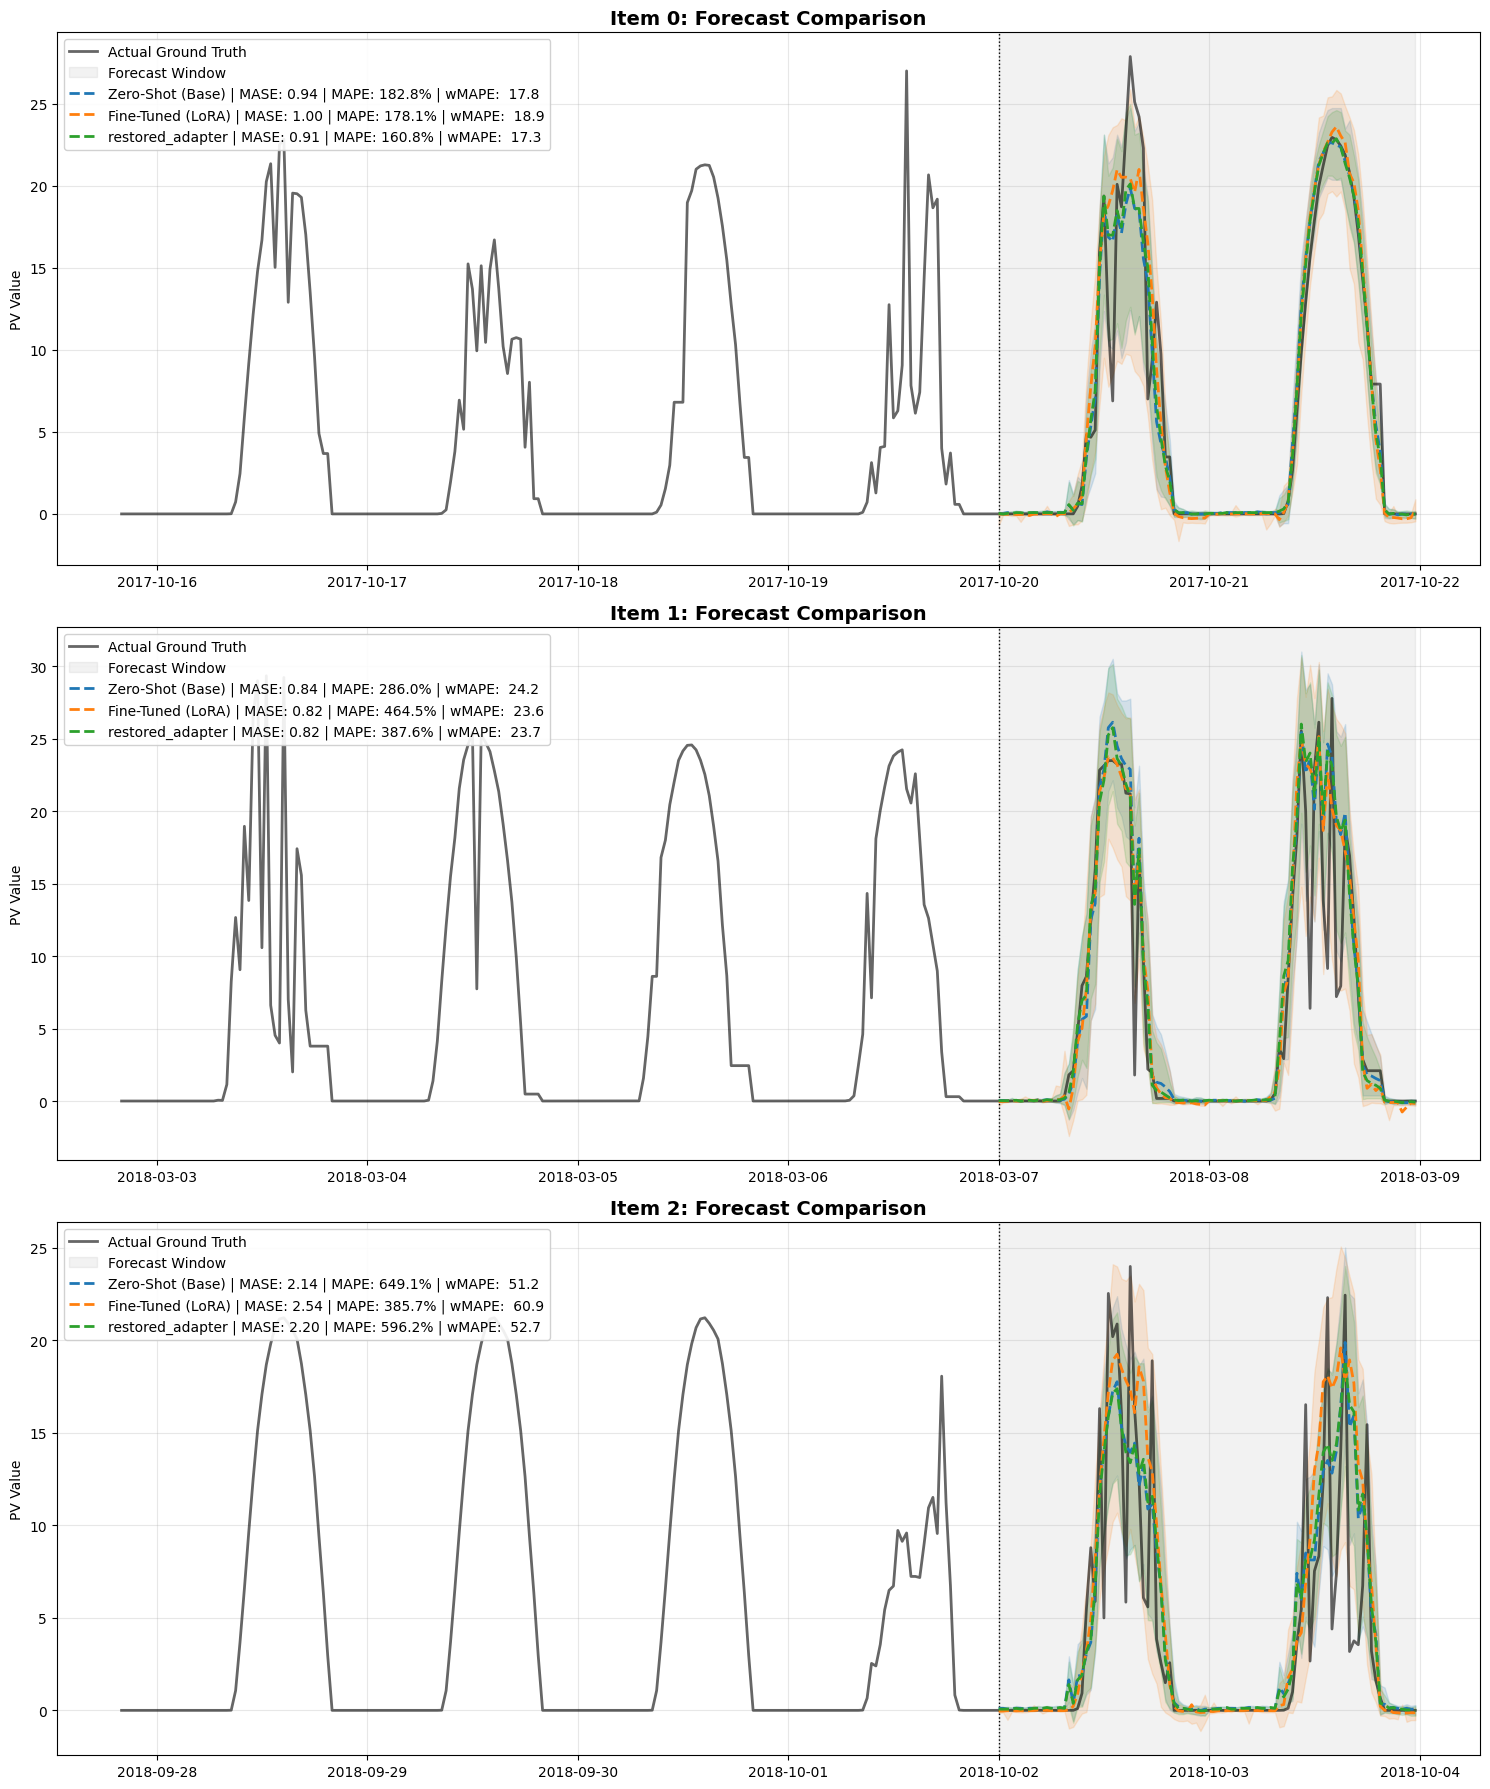

In [ ]:
# Define the dictionary of models you want to compare
# (Keys will appear in the legend)
models_to_plot = {
    "Zero-Shot (Base)": pred_df,
    "Fine-Tuned (LoRA)": lora_finetuned_pred_df,
    "restored_adapter": predictions
}

# Run the plot
plot_model_comparison(
    train_df=train_df,
    test_df=test_df,
    model_predictions=models_to_plot,
    plot_history_length=200,   # How many historical steps to show before the forecast
    prediction_length=PREDICTION_LENGTH,
    seasonality=96             # Seasonality for MASE (96 steps = 48 hours for 30min data)
)

Generating plots for 3 items...


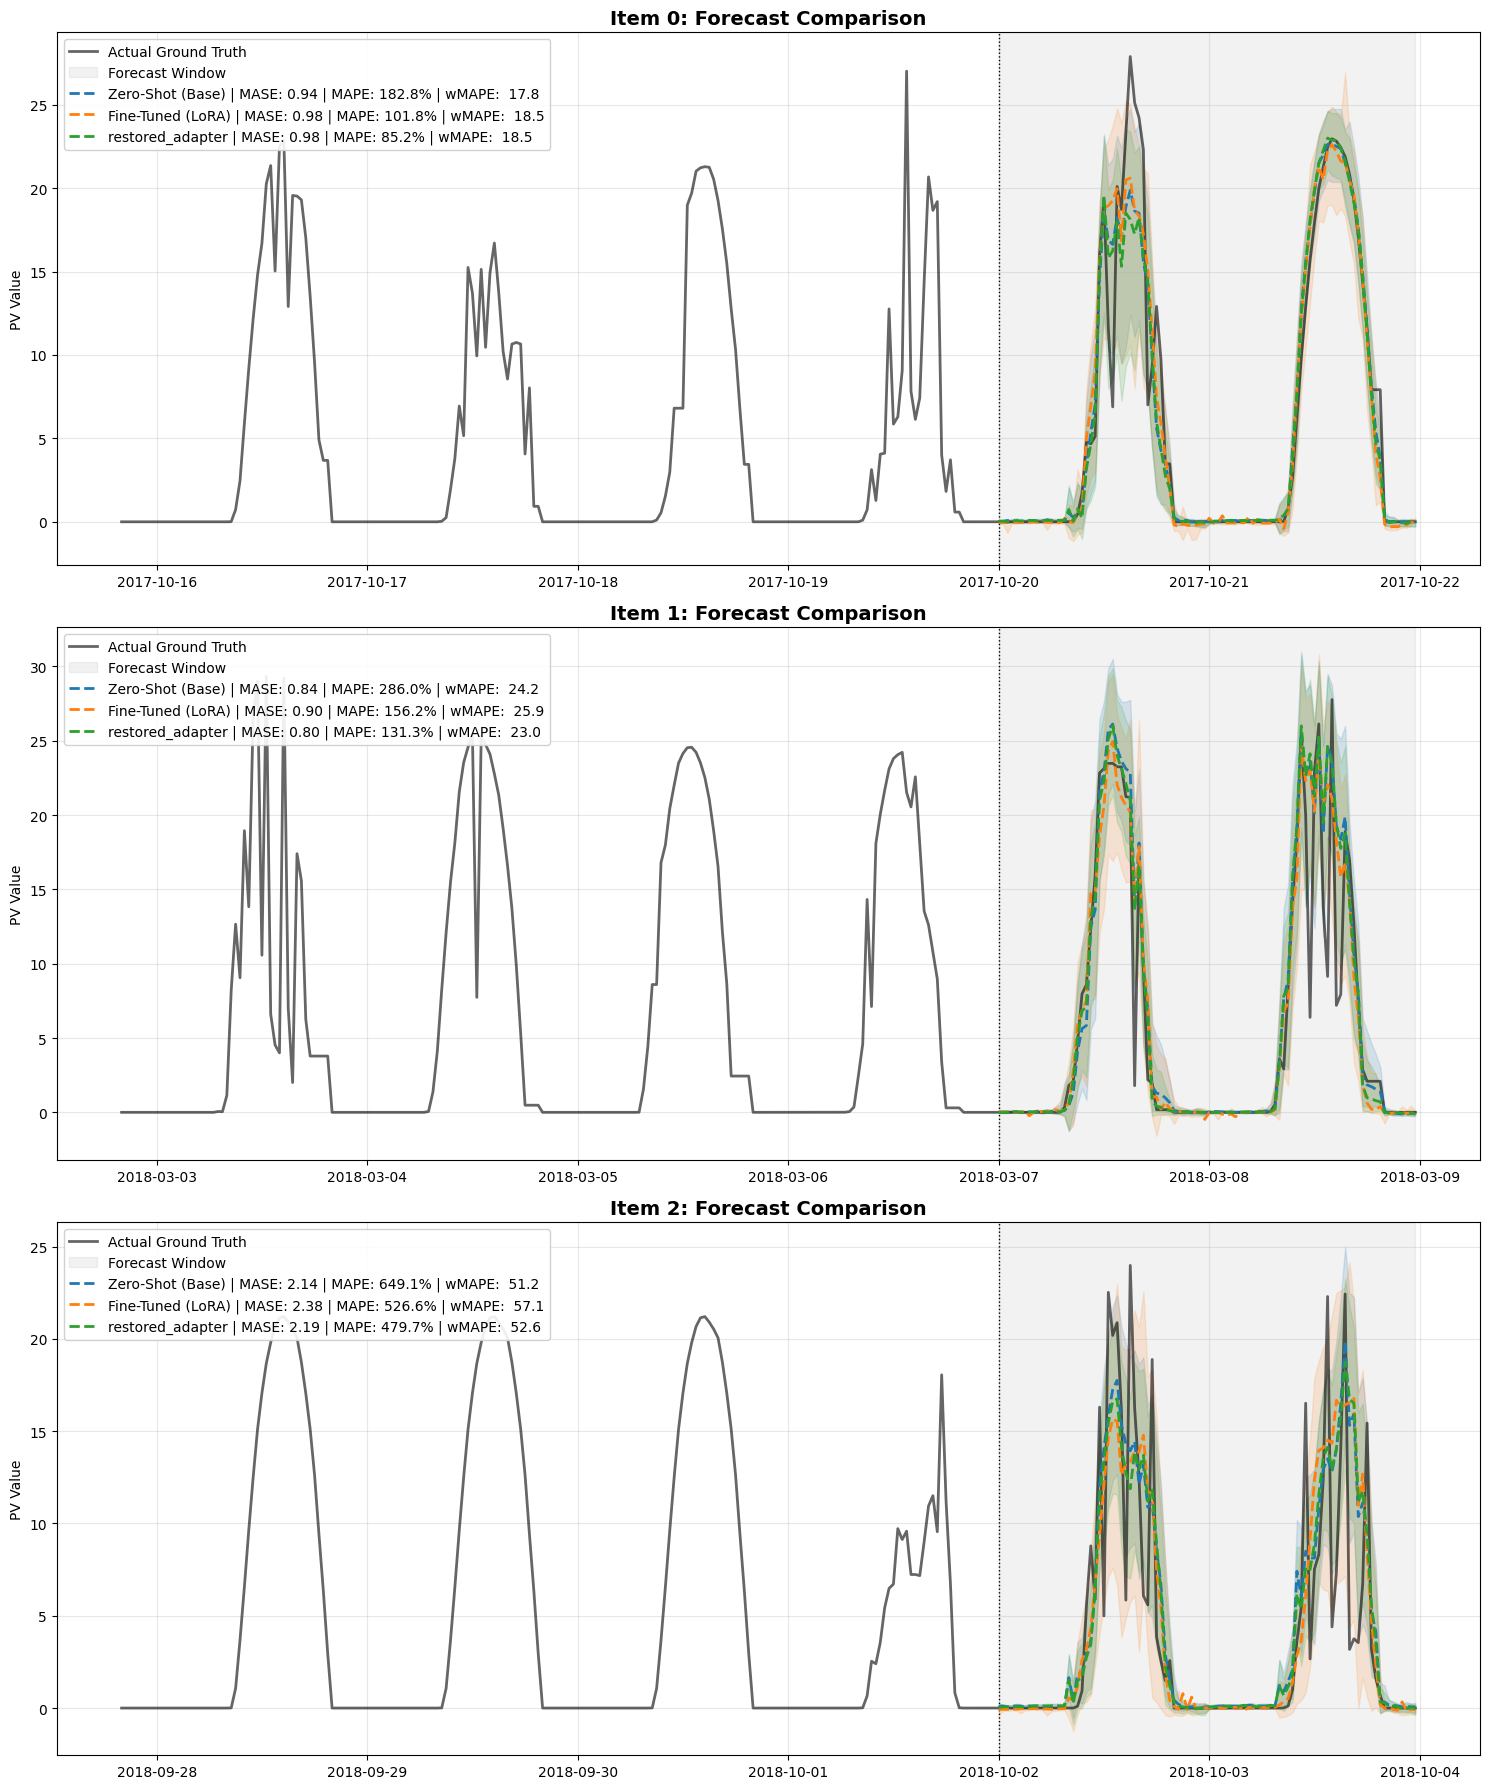

In [ ]:
# Define the dictionary of models you want to compare
# (Keys will appear in the legend)
models_to_plot = {
    "Zero-Shot (Base)": pred_df,
    "Fine-Tuned (LoRA)": lora_finetuned_pred_df,
    "restored_adapter": predictions
}

# Run the plot
plot_model_comparison(
    train_df=train_df,
    test_df=test_df,
    model_predictions=models_to_plot,
    plot_history_length=200,   # How many historical steps to show before the forecast
    prediction_length=PREDICTION_LENGTH,
    seasonality=96             # Seasonality for MASE (96 steps = 48 hours for 30min data)
)